## Objective

The objective of this analysis is to explore the relationship between demographic, clinical, and lifestyle-related factors and the occurrence of stroke, in order to identify potential risk patterns that could support preventive healthcare strategies

In [3]:
import pandas as pd

df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## Dataset Understanding

The dataset contains categorical and numerical variables distributed across 12 columns and 5,110 rows.

The information is organised into demographic, clinical, lifestyle, socio-demographic and target variables as follows:

- Demographic: age, gender  
- Clinical: hypertension, heart disease, glucose level and BMI  
- Lifestyle: smoking status  
- Socio-demographic: marital status, work type and residence type  
- Target: stroke  

The dataset includes both categorical and numerical variables with mixed data types such as object, float64 and int64.

Among the numerical variables, we can distinguish between float64 (age, glucose level and BMI) and int64 (hypertension, heart disease and stroke).

Regarding data quality issues, we observe that the BMI variable contains missing values (201 NaN).  
These missing values may affect the interpretation of the analysis and introduce potential bias.

Finally, we observe a strong imbalance in the target variable (stroke).  
Out of 5,110 patients, only 249 have experienced a stroke, representing approximately 4% of the dataset.

This imbalance may affect the analysis, as the stroke group is underrepresented, making comparisons between groups less robust.

Nonetheless, this imbalance is expected, as stroke has a lower prevalence compared to conditions such as hypertension or heart disease.

## Analysis Questions

- What is the relationship between age and gender with stroke occurrence?
- How does smoking status vary between patients with and without stroke?
- Is there any difference in stroke occurrence across different work types?
- Is there any association between residence type (urban/rural) and stroke occurrence?

## Data Cleaning

### Handling Missing Values (BMI)

Before deciding how to handle missing BMI values, an exploratory analysis was conducted to assess whether the missing data could introduce bias.

In [7]:
from IPython.display import display

# Create missing indicator
df['bmi_missing'] = df['bmi'].isna()

# Compare numerical variables
display(df.groupby('bmi_missing')['age'].mean())
display(df.groupby('bmi_missing')['stroke'].mean())
display(df.groupby('bmi_missing')['hypertension'].mean())

# Compare categorical variables
display(df.groupby('bmi_missing')['gender'].value_counts(normalize=True))
display(df.groupby('bmi_missing')['smoking_status'].value_counts(normalize=True))

,age
bmi_missing,
False,42.865374
True,52.049154


,stroke
bmi_missing,
False,0.042575
True,0.199005


,hypertension
bmi_missing,
False,0.091872
True,0.233831


bmi_missing  gender
False        Female    0.590141
             Male      0.409656
             Other     0.000204
True         Male      0.517413
             Female    0.482587
Name: proportion, dtype: float64

bmi_missing  smoking_status 
False        never smoked       0.377266
             Unknown            0.302098
             formerly smoked    0.170503
             smokes             0.150132
True         Unknown            0.303483
             smokes             0.258706
             formerly smoked    0.238806
             never smoked       0.199005
Name: proportion, dtype: float64

The analysis shows that patients with missing BMI values differ significantly from those with available BMI data.

Specifically, patients with missing BMI tend to be older and show higher proportions of stroke and hypertension. Differences are also observed in smoking status, suggesting a higher-risk profile.

These findings indicate that BMI values are not missing at random, and removing these observations could introduce bias by excluding higher-risk patients.

Therefore, missing BMI values were imputed using the median to preserve the dataset while minimizing distortion.

In [8]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [9]:
df['bmi'].describe()

,bmi
count,5110.000000
mean,28.862035
std,7.699562
min,10.300000
25%,23.800000
50%,28.100000
75%,32.800000
max,97.600000


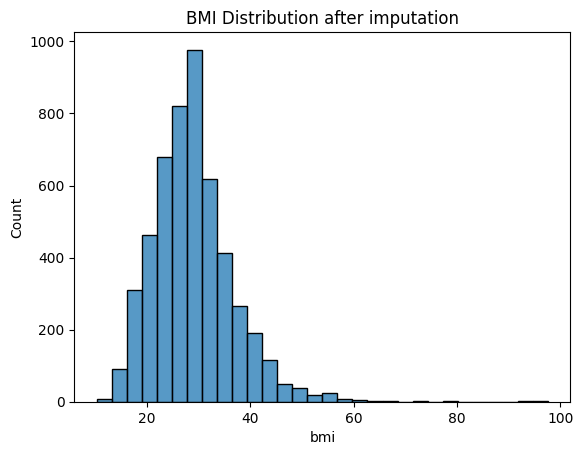

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['bmi'], bins=30)
plt.title("BMI Distribution after imputation")
plt.show()

The distribution of BMI appears approximately bell-shaped, with most values concentrated around 30.

There is a slight right skew, indicating the presence of higher BMI values extending the upper tail of the distribution.

This pattern is consistent with typical clinical data, where extreme values (e.g., obesity) can introduce some asymmetry.

### Removing Irrelevant Columns

The column `id` was removed as it serves only as a unique identifier and does not provide any analytical value for the study.

In [11]:
df = df.drop(columns=['id'])

### Handling categorical inconsistencies

The variables `gender` and `smoking_status` contain non-standard categories:

- `gender` includes a very small proportion of "Other"
- `smoking_status` includes "Unknown", which represents missing or unreported information

Given the exploratory nature of the analysis and the low frequency of these values, both categories were kept as they are to preserve data integrity and allow for potential pattern detection in later analysis.

## Exploratory Data Analysis (EDA)

This section explores the relationship between different variables and the occurrence of stroke, based on the previously defined analysis questions.

### Age and Stroke

To understand the relationship between age and stroke occurrence, we analyze how age is distributed across patients with and without stroke.

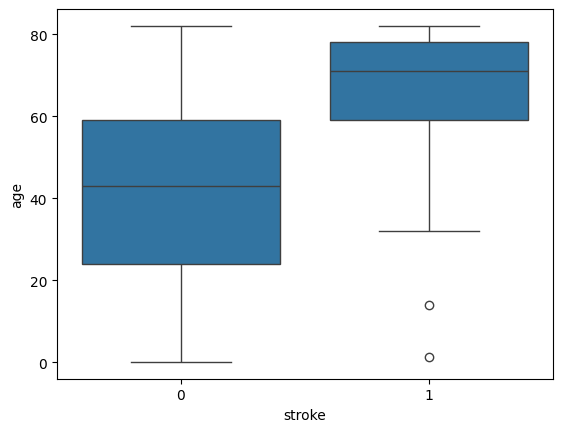

In [12]:
sns.boxplot(x='stroke', y='age', data=df)
plt.show()

### Age and Stroke

The distribution shows that patients without stroke are mainly concentrated between 20 and 60 years old, while patients who experienced a stroke are mostly between 60 and 80 years old.

From a clinical perspective, this suggests that age is a strong risk factor for stroke, with older patients being more affected.

This pattern is expected in real-world clinical practice, where stroke incidence increases with age. However, it is important to note that stroke can still occur in younger patients.

These findings suggest a potential strong association between age and stroke occurrence, which should be further explored alongside other clinical and lifestyle variables.

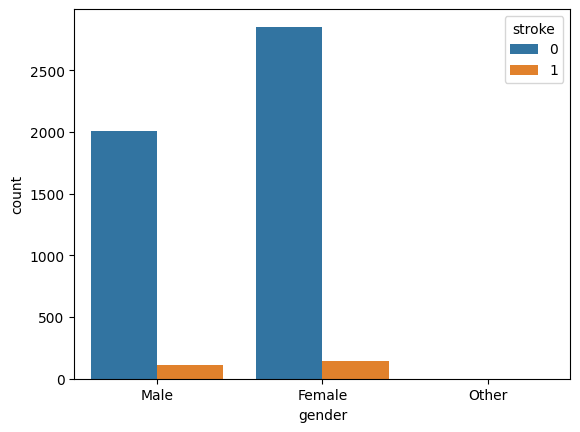

In [13]:
sns.countplot(x='gender', hue='stroke', data=df)
plt.show()

In [14]:
pd.crosstab(df['gender'], df['stroke'], normalize='index')

stroke,0,1
gender,,
Female,0.952906,0.047094
Male,0.948936,0.051064
Other,1.000000,0.000000


###Gender and Stroke

When comparing proportions within each gender group, the difference in stroke occurrence between males and females is small.

The distribution observed in both the countplot and the normalized crosstab shows very similar proportions of stroke across genders.

This suggests that gender does not appear to be a strong factor associated with stroke risk in this dataset.

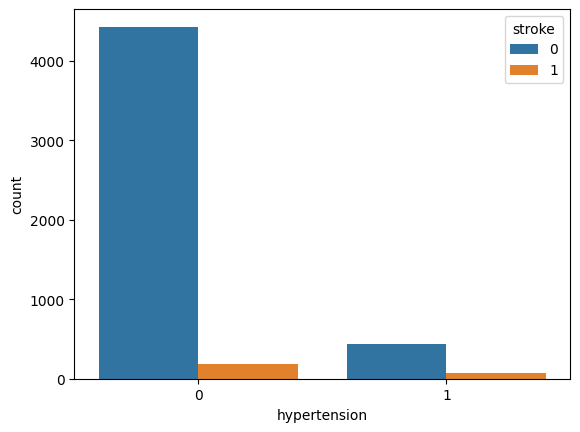

In [15]:
sns.countplot(x='hypertension', hue='stroke', data=df)
plt.show()

In [16]:
pd.crosstab(df['hypertension'], df['stroke'], normalize='index')

stroke,0,1
hypertension,,
0,0.960321,0.039679
1,0.867470,0.132530


### Hypertension and Stroke

The proportion of stroke cases is notably higher among patients with hypertension compared to those without.

While only around 4% of patients without hypertension experienced a stroke, this proportion increases to approximately 13% among patients with hypertension.

This suggests that hypertension may be an important risk factor associated with stroke occurrence in this dataset.

However, it is important to note that the majority of patients with hypertension did not experience a stroke, indicating that hypertension alone is not sufficient to explain stroke occurrence.

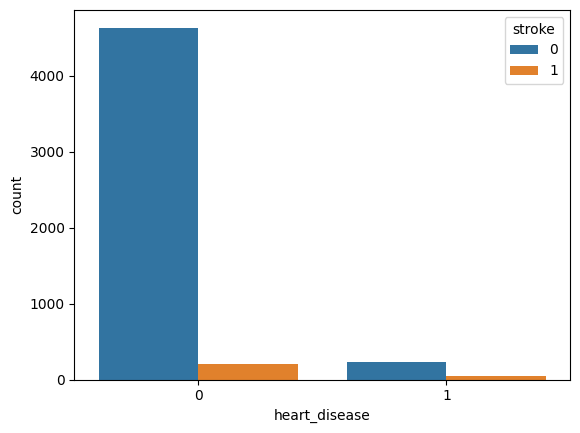

In [17]:
sns.countplot(x='heart_disease', hue='stroke', data=df)
plt.show()

In [18]:
pd.crosstab(df['heart_disease'], df['stroke'], normalize='index')

stroke,0,1
heart_disease,,
0,0.958213,0.041787
1,0.829710,0.170290


### Heart Disease and Stroke

Patients without heart disease show a stroke occurrence of approximately 4.1%, while patients with heart disease show a significantly higher proportion of around 17%.

This suggests a strong association between heart disease and increased stroke risk in this dataset.

Although the majority of patients with heart disease did not experience a stroke (82.9%), the probability of stroke is notably higher compared to patients without heart disease.

These results are consistent with clinical expectations, as cardiovascular conditions are known risk factors for stroke.

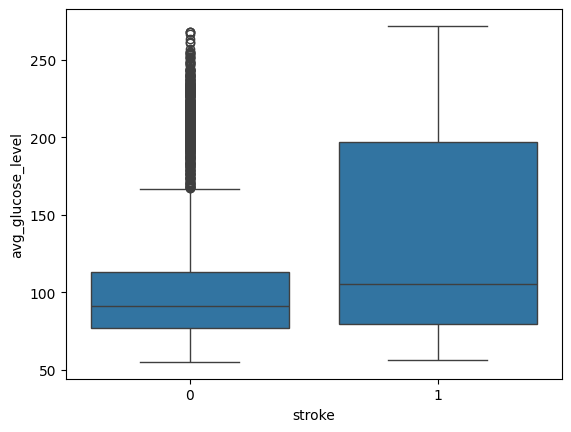

In [19]:
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
plt.show()

### Glucose Level and Stroke

Patients who experienced a stroke show a slightly higher median glucose level compared to those without stroke.

The distribution of glucose levels in the stroke group appears shifted towards higher values, suggesting a potential association between elevated glucose levels and stroke occurrence.

Although both groups show a wide range of values, the central tendency in the stroke group is higher, which may indicate that higher glucose levels are associated with increased stroke risk.

This pattern is consistent with clinical knowledge, where elevated blood glucose is considered a risk factor for vascular complications.

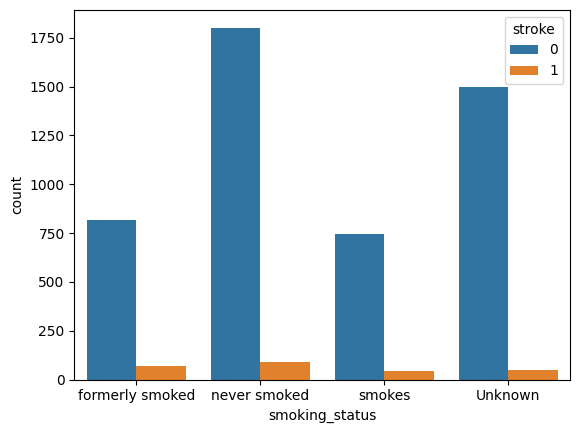

In [20]:
sns.countplot(x='smoking_status', hue='stroke', data=df)
plt.show()

In [21]:
pd.crosstab(df['smoking_status'], df['stroke'], normalize='index')

stroke,0,1
smoking_status,,
Unknown,0.969560,0.030440
formerly smoked,0.920904,0.079096
never smoked,0.952431,0.047569
smokes,0.946768,0.053232


### Smoking Status and Stroke

The proportion of stroke varies across smoking status categories.

Former smokers show the highest proportion of stroke cases (approximately 7.9%), followed by current smokers (5.3%) and individuals who never smoked (4.7%).

This suggests a potential association between smoking history and stroke risk, particularly among former smokers.

However, the differences between groups are relatively small, indicating that smoking status alone may not be a strong predictor of stroke in this dataset.

The "Unknown" category shows a lower proportion of stroke, but this group is difficult to interpret, as it likely includes missing or heterogeneous data.

Overall, smoking status may contribute to stroke risk, but should be analyzed in combination with other clinical variables.

<Axes: xlabel='ever_married', ylabel='count'>

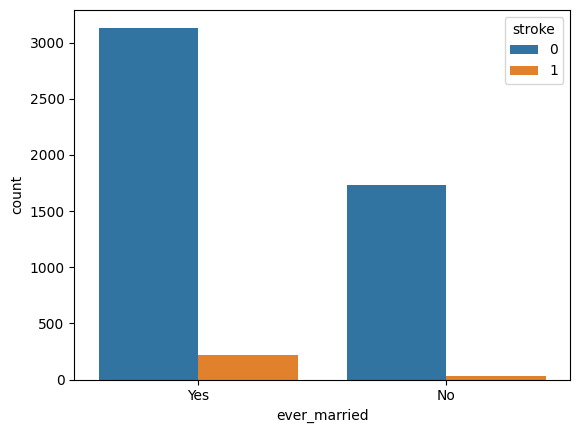

In [22]:
sns.countplot(x='ever_married', hue='stroke', data=df)

In [23]:
pd.crosstab(df['ever_married'], df['stroke'], normalize='index')

stroke,0,1
ever_married,,
No,0.983495,0.016505
Yes,0.934387,0.065613


In [24]:
df.groupby('ever_married')['age'].mean()

,age
ever_married,
No,22.014229
Yes,54.342082


### Marital Status and Stroke

Married individuals show a higher proportion of stroke compared to non-married individuals.

However, further analysis reveals a substantial age difference between the two groups: non-married individuals have an average age of approximately 22 years, while married individuals have an average age of around 54 years.

This suggests that the observed association between marital status and stroke is likely driven by age, a known major risk factor for stroke.

Therefore, marital status itself does not appear to be a direct risk factor, but rather a proxy for age in this dataset.

<Axes: xlabel='work_type', ylabel='count'>

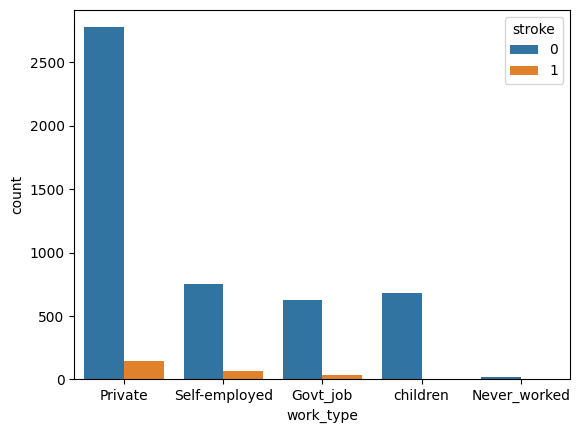

In [25]:
sns.countplot(x='work_type', hue='stroke', data=df)

In [26]:
pd.crosstab(df['work_type'], df['stroke'], normalize='index')

stroke,0,1
work_type,,
Govt_job,0.949772,0.050228
Never_worked,1.000000,0.000000
Private,0.949060,0.050940
Self-employed,0.920635,0.079365
children,0.997089,0.002911


<Axes: xlabel='Residence_type', ylabel='count'>

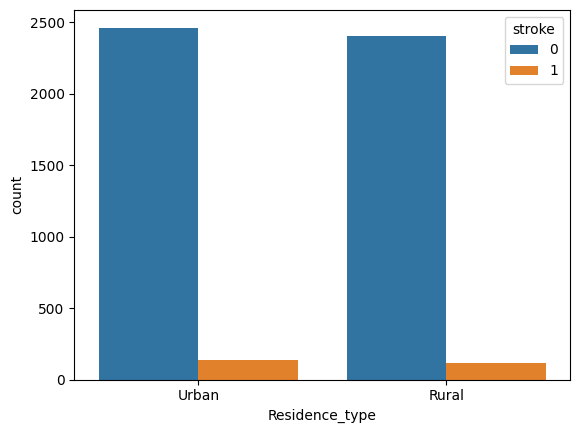

In [27]:
sns.countplot(x='Residence_type', hue='stroke', data=df)

In [28]:
pd.crosstab(df['Residence_type'], df['stroke'], normalize='index')

stroke,0,1
Residence_type,,
Rural,0.954654,0.045346
Urban,0.947997,0.052003


### Residence Type and Stroke

The proportion of stroke is very similar between rural and urban populations, with slightly higher values in urban areas (5.2% vs 4.5%).

These small differences suggest that residence type is not strongly associated with stroke risk in this dataset.

Therefore, residence type alone does not appear to be a meaningful predictor of stroke occurrence and should be interpreted in combination with other variables.

### Key Insights

- Age is the strongest factor associated with stroke, with higher proportions observed in older patients.
- Clinical conditions such as hypertension (13%) and heart disease (17%) show a strong association with stroke.
- Higher glucose levels are associated with stroke, with a noticeable shift in distribution.
- Former smokers show the highest proportion of stroke (7.9%), although differences between groups are moderate.
- Socio-demographic variables (work type, marital status, residence) show weak or indirect associations, often explained by age.

### Limitations

- The dataset is highly imbalanced, with a low proportion of stroke cases (~4%), which may affect the interpretation of results.
- Some variables contain missing or ambiguous values (e.g., BMI, smoking status "Unknown"), which may introduce bias.
- The analysis is based on observational data, so no causal relationships can be established.
- Potential confounding variables (such as age) may influence observed associations.

### Conclusion

This analysis identified age, hypertension, heart disease, and glucose levels as the variables most strongly associated with stroke occurrence. Lifestyle factors such as smoking also show a moderate association, while socio-demographic variables appear to have limited or indirect influence. These findings are consistent with clinical knowledge and highlight the importance of combining multiple factors when assessing stroke risk.

### Next Steps

- Develop a predictive model to estimate stroke risk based on key variables.
- Perform multivariate analysis to better control for confounding variables such as age.
- Explore feature engineering techniques to improve predictive performance.
- Validate findings using additional or more representative datasets.